WARNING    Note that the synaptic pathway 'synapses_1_pre' will run on the clock of the group 'spikegeneratorgroup_1' using a dt of 100. us. Either the Synapses object 'synapses_1' or the target 'neurongroup_1' (or both) are using a different dt. This might lead to unexpected results. In particular, all delays will be rounded to multiples of 100. us. If in doubt, try to ensure that 'spikegeneratorgroup_1', 'synapses_1', and 'neurongroup_1' use the same dt. [brian2.synapses.synapses.synapses_dt_mismatch]


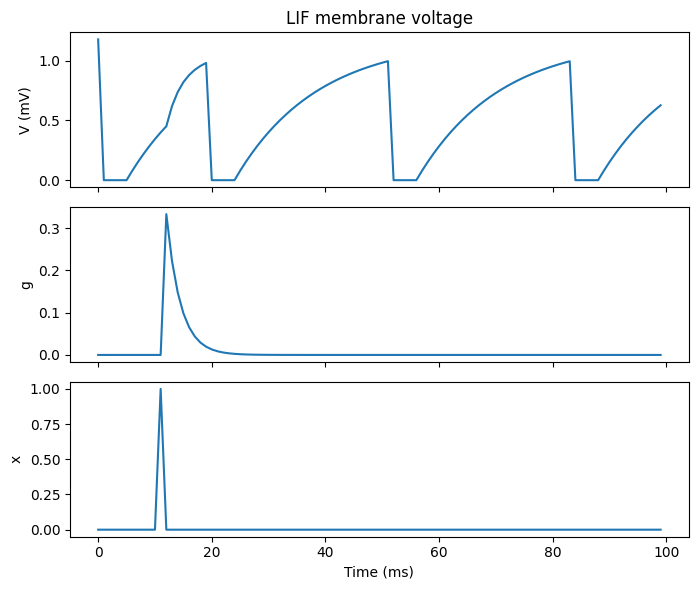

In [ ]:
import numpy as np
from brian2 import *
import matplotlib.pyplot as plt

start_scope()

# --- minimal LIF with placeholder synaptic current ---
rng = np.random.default_rng(seed=42)
mu = rng.uniform(1.1, 1.2)*mV 
refractory_t = 5*ms
tau = 15*ms
Vt = 1*mV
Vr = 0*mV

t1 = 1*ms
t2 = 3*ms

j_ee = 0.024

# TODO: remove dimensions

eqs = """
dV/dt = (mu - V) / tau + Isyn: volt (unless refractory)
Isyn  = 15*mV/ms * g * j_ee : volt/second

dg/dt = (x - g) / t2 : 1
dx/dt = -x / t1 : 1
"""

G = NeuronGroup(
    1,
    eqs,
    threshold='V > Vt',
    reset='V = Vr',
    refractory=refractory_t,
    method='euler',
    dt=1*ms
)
G.V = mu 

# sending a single input spike:
indices = np.array([0]) # index of neuron(s) that will fire
times = np.array([10])*ms # times at which neuron(s) fire
inp = SpikeGeneratorGroup(1, indices, times, dt=0.1*ms)

eqs_syn   = ''
# Update postsynaptic neuron state on incoming spike
eqs_onpre = 'x_post += ms*1/t1'

S = Synapses(inp, G, eqs_syn, on_pre=eqs_onpre, dt=0.1*ms)
S.connect()

M = StateMonitor(G, record=True, variables=['V', 'g', 'x'])
run(100*ms)

fig, axes = plt.subplots(3, 1, figsize=(7, 6), sharex=True)

axes[0].plot(M.t/ms, M.V[0]/mV)
axes[0].set_ylabel('V (mV)')
axes[0].set_title('LIF membrane voltage')

axes[1].plot(M.t/ms, M.g[0]/Hz)
axes[1].set_ylabel('g')

axes[2].plot(M.t/ms, M.x[0]/Hz)
axes[2].set_ylabel('x')
axes[2].set_xlabel('Time (ms)')

plt.tight_layout()
plt.show()
